<div dir="rtl" align="right">
<b>استيراد المكتبات</b><br>
نستورد مكتبة <code>cv2</code> لمعالجة الصور، و<code>matplotlib</code> لعرضها، و<code>numpy</code> لإنشاء مصفوفات التحويل الهندسي.
</div>

In [65]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

<div dir="rtl" align="right">
<b>قراءة الصورة الأصلية</b><br>
نحمّل صورة الأزهار من القرص وتُخزَّن في المتغير <code>image</code> بنظام BGR.
</div>

In [66]:
image = cv2.imread('flowers.jpg')

<div dir="rtl" align="right">
<b>عرض الصورة الأصلية</b><br>
نعرض الصورة الأصلية قبل تطبيق أي تحويل هندسي كمرجع للمقارنة.
</div>

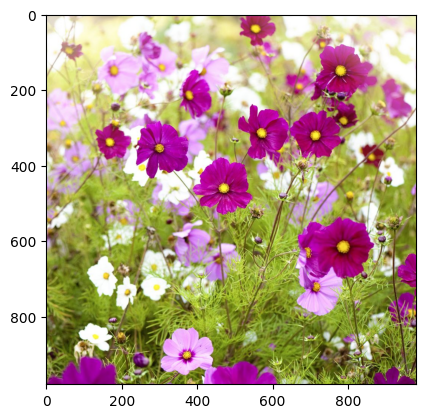

In [67]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

In [68]:
image.shape[0:2]

(980, 980)

<div dir="rtl" align="right">
<b>استخراج أبعاد الصورة وحساب مركزها</b><br>
نستخرج الارتفاع والعرض من خاصية <code>shape</code> ثم نحسب إحداثيات مركز الصورة.<br>
المركز ضروري لتحديد نقطة الدوران، وبدونه ستدور الصورة حول الزاوية العلوية اليسرى بدلاً من المركز.
</div>

In [69]:
height, width = image.shape[:2]
center= (width/2, height/2)
print(height, width,center)

980 980 (490.0, 490.0)


<div dir="rtl" align="right">
<b>إنشاء مصفوفة الدوران</b><br>
نستخدم <code>cv2.getRotationMatrix2D()</code> لإنشاء مصفوفة التحويل الثنائية الأبعاد (2×3) التي تصف عملية الدوران.<br>
— <code>center</code>: نقطة الدوران (مركز الصورة).<br>
— <code>angle=45</code>: زاوية الدوران بالدرجات عكس اتجاه عقارب الساعة.<br>
— <code>scale=1</code>: معامل التكبير، القيمة 1 تعني بدون تغيير في الحجم.
</div>

In [70]:
rotate_matrix = cv2.getRotationMatrix2D(center= center, angle=45, scale=1)
rotate_matrix

array([[   0.70710678,    0.70710678, -202.96464556],
       [  -0.70710678,    0.70710678,  490.        ]])

<div dir="rtl" align="right">
<b>تطبيق الدوران على الصورة</b><br>
نستخدم <code>cv2.warpAffine()</code> لتطبيق مصفوفة الدوران على الصورة.<br>
— <code>src</code>: الصورة المدخلة.<br>
— <code>M</code>: مصفوفة التحويل.<br>
— <code>dsize</code>: أبعاد الصورة الناتجة (عرض، ارتفاع). البكسلات الخارجة عن الحدود تملأ باللون الأسود.
</div>

In [71]:
rotated_image =  cv2.warpAffine(src = image, M =rotate_matrix , dsize=(width,height))

<div dir="rtl" align="right">
<b>عرض الصورة بعد الدوران</b><br>
نعرض الصورة بعد تدويرها 45 درجة حول مركزها. لاحظ ظهور مناطق سوداء في الزوايا حيث لا تغطي الصورة الإطار الكامل بعد الدوران.
</div>

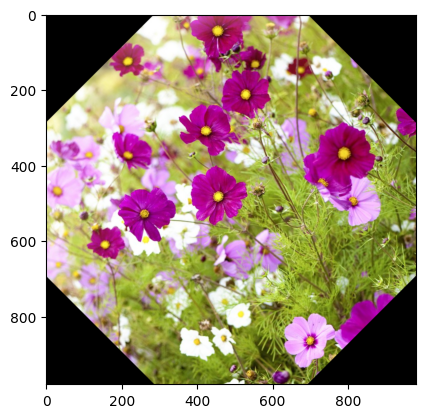

In [72]:
plt.imshow(cv2.cvtColor(rotated_image, cv2.COLOR_BGR2RGB))
plt.show()

x new = 1*x + 0*y + 245<br>
y new = 0*x + 1*y + 245

<div dir="rtl" align="right">
<b>إنشاء مصفوفة الإزاحة (Translation)</b><br>
نحدد مقدار الإزاحة: ربع العرض أفقياً وربع الارتفاع رأسياً.<br>
مصفوفة الإزاحة هي مصفوفة (2×3) بالشكل:<br>
<code>[[1, 0, tx],</code><br>
<code>&nbsp;[0, 1, ty]]</code><br>
حيث <code>tx</code> هي الإزاحة الأفقية و<code>ty</code> هي الإزاحة الرأسية بالبكسل.
</div>

In [76]:
tx = width/7
ty = height/7
tx=100
ty=0
translation_matrix = np.array([[1,0,tx],[0,1,ty]], dtype=np.float32)
translation_matrix

array([[  1.,   0., 100.],
       [  0.,   1.,   0.]], dtype=float32)

<div dir="rtl" align="right">
<b>تطبيق الإزاحة على الصورة</b><br>
نستخدم <code>cv2.warpAffine()</code> مرة أخرى لتطبيق مصفوفة الإزاحة، مما يحرّك الصورة نحو اليمين وللأسفل بمقدار ربع أبعادها. المناطق الفارغة تملأ باللون الأسود.
</div>

In [77]:
tranlated_image = cv2.warpAffine(src = image, M =translation_matrix , dsize=(width,height))

<div dir="rtl" align="right">
<b>عرض الصورة بعد الإزاحة</b><br>
نعرض الصورة بعد تطبيق الإزاحة. لاحظ ظهور أشرطة سوداء في الجهة اليسرى والعلوية حيث تركت الصورة فراغاً بعد تحركها.
</div>

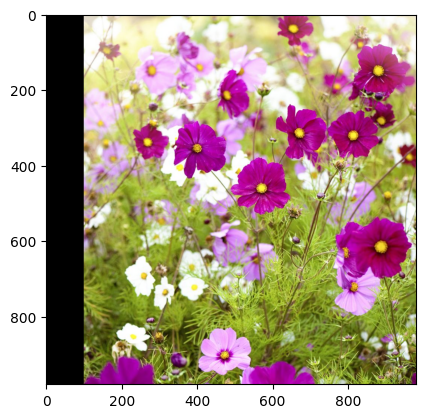

In [78]:
plt.imshow(cv2.cvtColor(tranlated_image, cv2.COLOR_BGR2RGB))
plt.show()